# EPISENCE: Disease Risk Prediction Model
This notebook trains the model to predict ward-level disease risk.

### Objective:
Predict `composite_risk_score` for 7 days into the future.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import joblib
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. Data Loading

In [2]:
DATA_DIR = "../data/"

def load_json(filename):
    file_path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(file_path):
        file_path = os.path.abspath(os.path.join(os.getcwd(), "EPISENCE/backend/data", filename))
        
    with open(file_path, 'r') as f:
        return json.load(f)

try:
    zones = pd.DataFrame(load_json("zones.json"))
    weather = pd.DataFrame(load_json("weather_data.json"))
    cases = pd.DataFrame(load_json("hospital_cases.json"))
    risk = pd.DataFrame(load_json("risk_scores.json"))

    weather['date'] = pd.to_datetime(weather['date'], format='ISO8601')
    cases['date'] = pd.to_datetime(cases['date'], format='ISO8601')
    risk['date'] = pd.to_datetime(risk['date'], format='ISO8601')
    print("Data Loaded Successfully!")
except Exception as e:
    print(f"Error loading data: {e}")

Data Loaded Successfully!


## 2. Training the Model

In [3]:
try:
    cases_agg = cases.groupby(['zone_id', 'date'])['case_count'].sum().reset_index()
    df = pd.merge(weather, cases_agg, on=['zone_id', 'date'], how='left').fillna(0)
    df = pd.merge(df, risk[['zone_id', 'date', 'composite_score']], on=['zone_id', 'date'], how='left')
    df['composite_score'] = df['composite_score'].ffill().bfill()

    df = df.sort_values(['zone_id', 'date'])
    new_df_list = []
    for zone_id, group in df.groupby('zone_id'):
        group = group.copy()
        group['target_risk_7d'] = group['composite_score'].shift(-7)
        new_df_list.append(group)

    df = pd.concat(new_df_list).dropna(subset=['target_risk_7d'])
    X = df[['temperature_avg', 'humidity_avg', 'rainfall_mm', 'case_count']]
    y = df['target_risk_7d']

    model = GradientBoostingRegressor(random_state=42)
    model.fit(X, y)
    print("Model Trained Successfully!")
except Exception as e:
    print(f"Error in training: {e}")

Model Trained Successfully!


## 3. Visualization

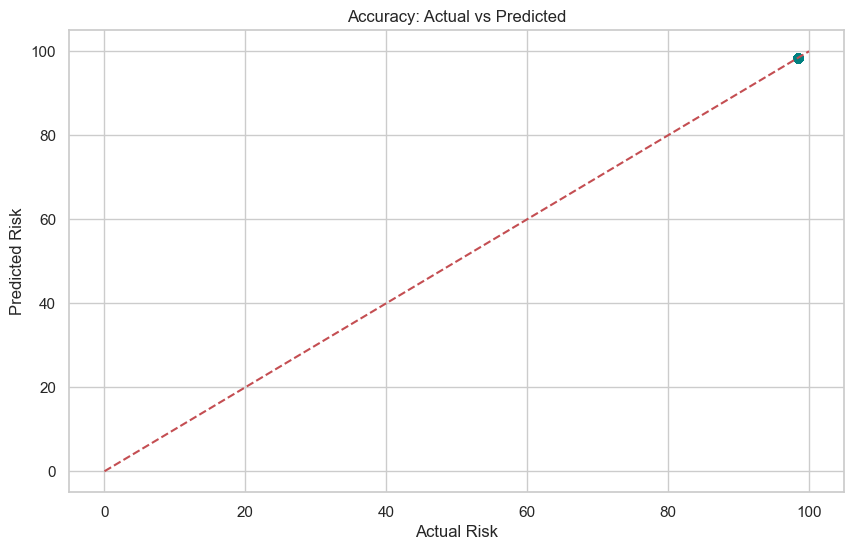

In [4]:
try:
    y_pred = model.predict(X)
    plt.figure(figsize=(10, 6))
    plt.scatter(y, y_pred, alpha=0.5, color='teal')
    plt.plot([0, 100], [0, 100], '--r')
    plt.xlabel("Actual Risk")
    plt.ylabel("Predicted Risk")
    plt.title("Accuracy: Actual vs Predicted")
    plt.show()
except Exception as e:
    print(f"Error in visualization: {e}")